# 1D Pyrite Oxidation with `from_mf6`

This is the **same** Appelo et al. (1998) pyrite-oxidation column as the
[previous tutorial](tutorial02), solved with the **transport-first**
:meth:`~mf6rtm.mup3d.base.Mup3d.from_mf6` workflow instead of the classic one.

Rather than building one transport model per component yourself, you build an
ordinary MODFLOW 6 flow model plus a **single conservative tracer** transport
model, then hand it to ``from_mf6``, which clones that tracer model into one
reactive model per PHREEQC component. The inflow chemistry is switched per
stress period (dilute in period 0, oxidising in period 1) with a single
``ChemStress('wel', type='aux').set_spd({0: [2], 1: [3]})`` call.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import flopy

from mf6rtm import utils, mup3d

BASE = "." if os.path.isdir("data") else os.path.join("docs", "tutorials")
DATA = os.path.join(BASE, "data")

## 1. Discretization and flow

Identical column to the classic tutorial: 5.3 cm in 16 cells, two stress
periods (dilute then oxidising flush). The injection well carries a single
``tracer`` auxiliary; ``from_mf6`` replaces it with one aux column per
component at ``write_simulation()``.

In [2]:
length_units = "meters"
time_units = "days"

nlay, nrow, ncol = 1, 1, 16
Lx = 0.053
delr = Lx / ncol
delc = 1.0
top = 2.87433e-03
botm = np.linspace(top, 0.0, nlay + 1)[1:]

k11 = 1.0
prsity = 0.376
dispersivity = 0.00537

q = 2.4e-4  # injection rate (m3/d)

nper = 2
nstp = [64, 100]
perlen = [0.9333, 1.45833]
tdis_rc = [(pl, ns, 1.0) for pl, ns in zip(perlen, nstp)]

# WEL carries a single 'tracer' aux (placeholder 1.0) in both periods
wel_spd = {kper: [[(0, 0, 0), q, 1.0]] for kper in range(nper)}
chdspd = [[(0, 0, ncol - 1), 1.0]]

## 2. Build the flow + tracer transport model

A GWF flow model plus **one** conservative tracer GWT whose SSM sources the
well ``tracer`` auxiliary. This is the ordinary MODFLOW 6 model you would
build for conservative transport — ``from_mf6`` takes it from here.

In [3]:
sim_ws = os.path.join(BASE, "_tutorial03_run")
sim = flopy.mf6.MFSimulation(sim_name="pyrite_from_mf6", sim_ws=sim_ws, exe_name="mf6")
flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=tdis_rc, time_units=time_units)

# --- GWF ---
gwf = flopy.mf6.ModflowGwf(sim, modelname="gwf", save_flows=True)
imsgwf = flopy.mf6.ModflowIms(sim, complexity="complex", linear_acceleration="CG",
                              filename="gwf.ims")
sim.register_ims_package(imsgwf, ["gwf"])

flopy.mf6.ModflowGwfdis(gwf, length_units=length_units, nlay=nlay, nrow=nrow, ncol=ncol,
                        delr=delr, delc=delc, top=top, botm=botm, filename="gwf.dis")
flopy.mf6.ModflowGwfnpf(gwf, save_specific_discharge=True, save_saturation=True,
                        icelltype=1, k=k11, filename="gwf.npf")
flopy.mf6.ModflowGwfic(gwf, strt=1.0, filename="gwf.ic")
flopy.mf6.ModflowGwfwel(gwf, stress_period_data=wel_spd, auxiliary=["tracer"],
                        pname="wel", filename="gwf.wel")
flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chdspd, pname="chd", filename="gwf.chd")
flopy.mf6.ModflowGwfoc(gwf, head_filerecord="gwf.hds", budget_filerecord="gwf.cbb",
                       saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])

# --- single conservative tracer GWT (the from_mf6 template) ---
gwt = flopy.mf6.ModflowGwt(sim, modelname="tracer")
imsgwt = flopy.mf6.ModflowIms(sim, linear_acceleration="BICGSTAB", filename="tracer.ims")
sim.register_ims_package(imsgwt, ["tracer"])

flopy.mf6.ModflowGwtdis(gwt, length_units=length_units, nlay=nlay, nrow=nrow, ncol=ncol,
                        delr=delr, delc=delc, top=top, botm=botm, filename="tracer.dis")
flopy.mf6.ModflowGwtic(gwt, strt=0.0, filename="tracer.ic")
flopy.mf6.ModflowGwtssm(gwt, sources=[["wel", "aux", "tracer"]], filename="tracer.ssm")
flopy.mf6.ModflowGwtadv(gwt, scheme="tvd")
flopy.mf6.ModflowGwtdsp(gwt, xt3d_off=True, alh=dispersivity, ath1=dispersivity * 0.1,
                        filename="tracer.dsp")
flopy.mf6.ModflowGwtmst(gwt, porosity=prsity, filename="tracer.mst")
flopy.mf6.ModflowGwtoc(gwt, concentration_filerecord="tracer.ucn",
                       saverecord=[("CONCENTRATION", "ALL")])
flopy.mf6.ModflowGwfgwt(sim, exgtype="GWF6-GWT6", exgmnamea="gwf", exgmnameb="tracer",
                        filename="tracer.gwfgwt")

package_name = tracer.gwfgwt
filename = tracer.gwfgwt
package_type = gwfgwt
model_or_simulation_package = simulation
simulation_name = pyrite_from_mf6


## 3. Geochemistry — the pyrite reaction network

The chemistry is identical to the classic tutorial (the ``mup3d`` classes are
workflow-agnostic): initial pore water (**Solutions**), four-zone cation
**ExchangePhases**, kinetic pyrite + organic matter (**KineticPhases**),
calcite (**EquilibriumPhases**) and surface complexation (**Surfaces**).

In [4]:
solutionsdf = pd.read_csv(os.path.join(DATA, "tut02_solutions.csv"),
                          comment="#", index_col=0)
solution = mup3d.Solutions(utils.solution_df_to_dict(solutionsdf))
solution.set_ic(np.ones((nlay, nrow, ncol), dtype=float))

# cation exchanger with four spatial zones
excdf = pd.read_csv(os.path.join(DATA, "tut02_exchange.csv"), comment="#", index_col=0)
excdf.columns = [0, 1, 2, 3]
exchanger_dict = excdf.to_dict()
for _z, subdict in exchanger_dict.items():
    for key in subdict:
        subdict[key] = {"m0": subdict[key]}
exchanger = mup3d.ExchangePhases(exchanger_dict)
exchanger_ic = np.ones((nlay, nrow, ncol), dtype=float)
exchanger_ic[0, 0, :4] = 1
exchanger_ic[0, 0, 4:8] = 2
exchanger_ic[0, 0, 8:12] = 3
exchanger_ic[0, 0, 12:] = 4
exchanger.set_ic(exchanger_ic)
exchanger.set_equilibrate_solutions([1, 1, 1, 1])

# kinetic pyrite + organic matter
kin_df = pd.read_csv(os.path.join(DATA, "tut02_kinetic_phases.csv"))
kin_phases = utils.parse_kinetics_dataframe(kin_df)
kin_phases[1]["Orgc_sed"]["formula"] = "Orgc_sed -1.0 C 1.0"
kinetics = mup3d.KineticPhases(kin_phases)
kinetics.set_ic(1)

# equilibrium phases + surfaces
eqp_df = pd.read_csv(os.path.join(DATA, "tut02_equilibrium_phases.csv"))
equilibriums = mup3d.EquilibriumPhases(utils.parse_equilibriums_dataframe(eqp_df))
equilibriums.set_ic(1)

surfaces = mup3d.Surfaces(utils.surfaces_csv_to_dict(
    os.path.join(DATA, "tut02_surfaces.csv")))
surfaces.set_ic(1)

## 4. Couple with `from_mf6` and set the per-period inflow

``from_mf6`` reads the grid from the GWF model and stores the ``tracer`` GWT as
the template to clone. The inflow well switches solution **by stress period**
via a dict: solution 2 (dilute) in period 0, solution 3 (oxidising) in period 1.

In [5]:
model = mup3d.Mup3d.from_mf6(sim, solution, name="pyrite_from_mf6", gwt_name="tracer")
model.set_wd(sim_ws)
model.set_database(os.path.join(DATA, "tut02_datab.dat"))
model.set_initial_temp([7.0, 7.0, 7.0])
model.set_postfix(os.path.join(DATA, "tut02_postfix.phqr"))

model.set_exchange_phases(exchanger)
model.set_phases(kinetics)
model.set_phases(equilibriums)
model.set_phases(surfaces)

model.initialize()

wellchem = mup3d.ChemStress("wel", type="aux")
wellchem.set_spd({0: [2], 1: [3]})  # period 0 -> solution 2, period 1 -> solution 3
model.set_chem_stress(wellchem)

Using temperatue of 7.0 from SOLUTION 1 for all cells
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Min concentration: None (no clipping)
  Reactions calculated at all time steps
Phreeqc initialized
Initializing ChemStress
ChemStress wel initialized


## 5. Write and run

In [6]:
model.write_simulation()

# Stage the platform's MODFLOW 6 binaries into the run directory (pixi fetches
# them into ``benchmark/bin``) so the solver finds libmf6 locally.
utils.prep_bins(model.wd, src_path=os.path.join(BASE, "..", "..", "benchmark", "bin"))

model.run()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing solution package ims_1...
  writing solution package ims_2...
  writing solution package ims_3...
  writing solution package ims_4...
  writing solution package ims_5...
  writing solution package ims_6...
  writing solution package ims_7...
  writing solution package ims_8...
  writing solution package ims_9...
  writing solution package ims_10...
  writing package H.gwfgwt...
  writing package O.gwfgwt...
  writing package Charge.gwfgwt...
  writing package C.gwfgwt...
  writing package Ca.gwfgwt...
  writing package Cl.gwfgwt...
  writing package Fe.gwfgwt...
  writing package Mg.gwfgwt...
  writing package Orgc_sed.gwfgwt...
  writing package S.gwfgwt...
  writing model gwf...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package wel...
INFORMATION: maxbound in ('gwf6'

Using libmf6 found in model directory: libmf6.dylib


Processing initial chemistry configuration
Starting Solution at 2026-07-20 15:57:09
Transport       | Stress period:  1     | Time step:      1          | Completed in :  0 min   1.30e-06 sec
Reactions       | Stress period:  1     | Time step:      1          | Completed in :  0 min   1.13e-04 sec
Transport       | Stress period:  1     | Time step:      2          | Completed in :  0 min   1.22e-06 sec
Reactions       | Stress period:  1     | Time step:      2          | Completed in :  0 min   9.13e-04 sec
Transport       | Stress period:  1     | Time step:      3          | Completed in :  0 min   1.98e-06 sec
Reactions       | Stress period:  1     | Time step:      3          | Completed in :  0 min   7.52e-04 sec
Transport       | Stress period:  1     | Time step:      4          | Completed in :  0 min   1.70e-06 sec
Reactions       | Stress period:  1     | Time step:      4          | Completed in :  0 min   5.63e-04 sec
Transport       | Stress period:  1     | Time step:

Transport       | Stress period:  1     | Time step:      6          | Completed in :  0 min   1.55e-06 sec
Reactions       | Stress period:  1     | Time step:      6          | Completed in :  0 min   5.60e-04 sec
Transport       | Stress period:  1     | Time step:      7          | Completed in :  0 min   1.47e-06 sec
Reactions       | Stress period:  1     | Time step:      7          | Completed in :  0 min   5.43e-04 sec
Transport       | Stress period:  1     | Time step:      8          | Completed in :  0 min   1.45e-06 sec
Reactions       | Stress period:  1     | Time step:      8          | Completed in :  0 min   5.34e-04 sec
Transport       | Stress period:  1     | Time step:      9          | Completed in :  0 min   1.38e-06 sec
Reactions       | Stress period:  1     | Time step:      9          | Completed in :  0 min   5.27e-04 sec
Transport       | Stress period:  1     | Time step:      10         | Completed in :  0 min   1.42e-06 sec
Reactions       | Stress per

Reactions       | Stress period:  1     | Time step:      11         | Completed in :  0 min   4.91e-04 sec
Transport       | Stress period:  1     | Time step:      12         | Completed in :  0 min   1.53e-06 sec
Reactions       | Stress period:  1     | Time step:      12         | Completed in :  0 min   4.83e-04 sec
Transport       | Stress period:  1     | Time step:      13         | Completed in :  0 min   1.68e-06 sec
Reactions       | Stress period:  1     | Time step:      13         | Completed in :  0 min   4.53e-04 sec
Transport       | Stress period:  1     | Time step:      14         | Completed in :  0 min   1.97e-06 sec
Reactions       | Stress period:  1     | Time step:      14         | Completed in :  0 min   4.34e-04 sec
Transport       | Stress period:  1     | Time step:      15         | Completed in :  0 min   2.80e-06 sec
Reactions       | Stress period:  1     | Time step:      15         | Completed in :  0 min   4.07e-04 sec
Transport       | Stress per

...

Reactions       | Stress period:  2     | Time step:      86         | Completed in :  0 min   6.47e-04 sec
Transport       | Stress period:  2     | Time step:      87         | Completed in :  0 min   8.00e-07 sec
Reactions       | Stress period:  2     | Time step:      87         | Completed in :  0 min   6.34e-04 sec
Transport       | Stress period:  2     | Time step:      88         | Completed in :  0 min   8.83e-07 sec
Reactions       | Stress period:  2     | Time step:      88         | Completed in :  0 min   6.37e-04 sec
Transport       | Stress period:  2     | Time step:      89         | Completed in :  0 min   8.50e-07 sec
Reactions       | Stress period:  2     | Time step:      89         | Completed in :  0 min   6.49e-04 sec
Transport       | Stress period:  2     | Time step:      90         | Completed in :  0 min   7.33e-07 sec
Reactions       | Stress period:  2     | Time step:      90         | Completed in :  0 min   6.53e-04 sec
Transport       | Stress per

Reactions       | Stress period:  2     | Time step:      91         | Completed in :  0 min   6.80e-04 sec
Transport       | Stress period:  2     | Time step:      92         | Completed in :  0 min   7.67e-07 sec
Reactions       | Stress period:  2     | Time step:      92         | Completed in :  0 min   6.75e-04 sec
Transport       | Stress period:  2     | Time step:      93         | Completed in :  0 min   7.67e-07 sec
Reactions       | Stress period:  2     | Time step:      93         | Completed in :  0 min   6.74e-04 sec
Transport       | Stress period:  2     | Time step:      94         | Completed in :  0 min   8.67e-07 sec
Reactions       | Stress period:  2     | Time step:      94         | Completed in :  0 min   6.56e-04 sec
Transport       | Stress period:  2     | Time step:      95         | Completed in :  0 min   7.33e-07 sec
Reactions       | Stress period:  2     | Time step:      95         | Completed in :  0 min   6.56e-04 sec
Transport       | Stress per

Reactions       | Stress period:  2     | Time step:      96         | Completed in :  0 min   6.80e-04 sec
Transport       | Stress period:  2     | Time step:      97         | Completed in :  0 min   8.50e-07 sec
Reactions       | Stress period:  2     | Time step:      97         | Completed in :  0 min   6.73e-04 sec
Transport       | Stress period:  2     | Time step:      98         | Completed in :  0 min   7.50e-07 sec
Reactions       | Stress period:  2     | Time step:      98         | Completed in :  0 min   6.47e-04 sec
Transport       | Stress period:  2     | Time step:      99         | Completed in :  0 min   7.50e-07 sec
Reactions       | Stress period:  2     | Time step:      99         | Completed in :  0 min   6.85e-04 sec
Transport       | Stress period:  2     | Time step:      100        | Completed in :  0 min   7.50e-07 sec
Reactions       | Stress period:  2     | Time step:      100        | Completed in :  0 min   7.12e-04 sec

MODFLOW 6 converged success


MODEL RUN FINISHED BUT CHECK THE RESULTS

Solution finished at 2026-07-20 15:57:14. Running time:   0.085165 mins


True

## 6. Results: effluent breakthrough curves

Outlet-cell concentrations versus cumulative effluent volume, compared with the
measured effluent data of Appelo et al. (1998). This is the same result as the
classic tutorial, reached through the transport-first workflow.

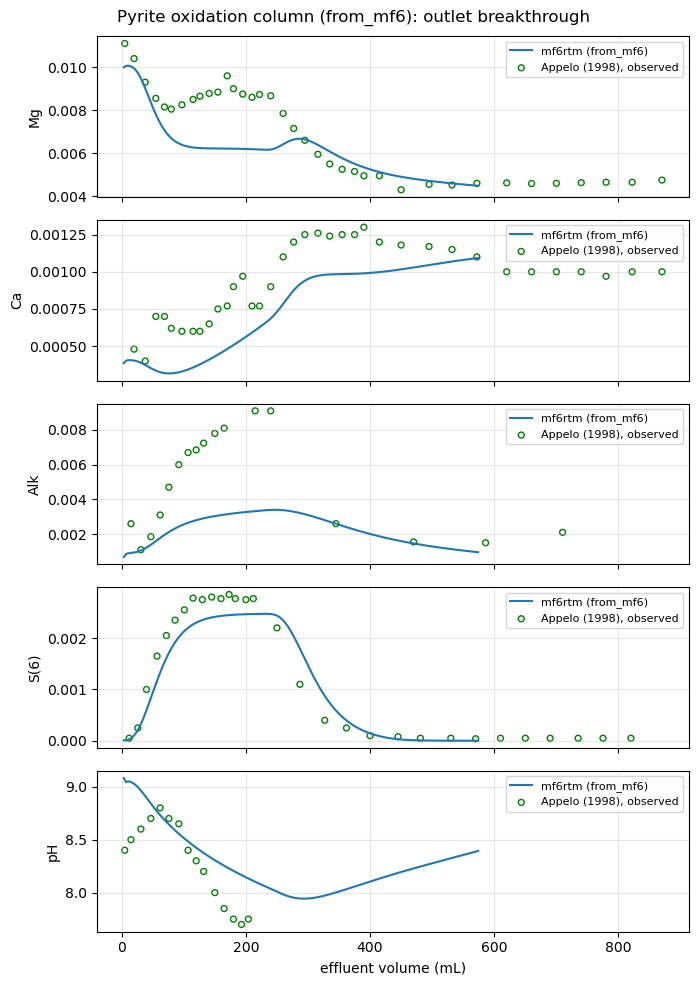

In [7]:
sout = pd.read_csv(os.path.join(model.wd, "sout.csv"))
qml = q * 1.0e6  # m3/d -> mL/d, so time (d) * qml = effluent volume (mL)
outlet = sout[sout["col"] == sout["col"].max()].copy()
outlet["vol"] = outlet["time_d"] * qml

# Measured effluent data (real experiment, not a model benchmark).
obs = pd.read_csv(os.path.join(DATA, "tut02_obs.txt"), sep="\t", skipinitialspace=True)
obs.replace(-9999, np.nan, inplace=True)
obs.dropna(axis=0, how="all", inplace=True)
obs.columns = ["vol", "Mg", "Ca", "Alk", "Cl", "S(6)", "pH"]
obs.set_index("vol", inplace=True)
obs = obs.iloc[3:, :]

plot_vars = [v for v in ["Mg", "Ca", "Alk", "S(6)", "pH"] if v in outlet.columns]

fig, axs = plt.subplots(len(plot_vars), 1, figsize=(7, 2.0 * len(plot_vars)),
                        sharex=True)
for ax, var in zip(np.atleast_1d(axs), plot_vars):
    ax.plot(outlet["vol"], outlet[var], color="tab:blue", zorder=10, label="mf6rtm (from_mf6)")
    if var in obs.columns:
        ax.scatter(obs.index, obs[var], s=18, facecolors="none",
                   edgecolors="green", label="Appelo (1998), observed")
    ax.set_ylabel(var)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
np.atleast_1d(axs)[-1].set_xlabel("effluent volume (mL)")
fig.suptitle("Pyrite oxidation column (from_mf6): outlet breakthrough")
fig.tight_layout()